In [109]:
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon, Wedge

VIDEO_PATH = "media/videos/test.mp4"

In [110]:
def rotated_ncc_templates(gray_icon_img, angles=(0,60,120,180,240,300)):
    h, w = gray_icon_img.shape[:2]
    c = (w/2.0, h/2.0)
    out = []
    for a in angles:
        M = cv2.getRotationMatrix2D(c, a, 1.0)
        rot = cv2.warpAffine(gray_icon_img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        rot = cv2.GaussianBlur(rot, (3,3), 0)
        out.append(rot)
    return out

class Template:
    def __init__(self, path, orb):
        self.path = path
        self.name = os.path.splitext(os.path.basename(path))[0]

        self.img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if self.img is None:
            raise FileNotFoundError(path)

        self.ncc_img = cv2.GaussianBlur(self.img, (3, 3), 0)
        self.ncc_h, self.ncc_w = self.ncc_img.shape[:2]
        self.ncc_rots = rotated_ncc_templates(self.img)

        self.kp, self.des = orb.detectAndCompute(self.img, None)
        if self.des is None:
            raise RuntimeError(f"No features in {path}")

        h, w = self.img.shape[:2]
        self.corners = np.float32(
            [[0,0],[w-1,0],[w-1,h-1],[0,h-1]]
        ).reshape(-1,1,2)


In [111]:
def load_templates(folder, orb):
    templates = {}
    for p in glob.glob(os.path.join(folder, "*.*")):
        t = Template(p, orb)
        templates[t.name] = t
    return templates

In [112]:
class MapTile:
    def __init__(self, tile_type="empty", owner="none"):
        self.type = tile_type
        self.owner = owner

        if self.type == "forest":
            self.color = "green"
        elif self.type == "city":
            self.color = "grey"
        elif self.type == "ocean":
            self.color = "blue"
        else:
            self.color = "none"


class Map:
    def __init__(self, hex_size=1.0):
        # Terraforming Mars board shape
        self.row_lengths = [5, 6, 7, 8, 9, 8, 7, 6, 5]
        self.rows = len(self.row_lengths)
        self.hex_size = hex_size

        # (row, col) -> tile type (None, "forest", later "city", "ocean")
        self.tiles = {}

        # (row, col) -> (x, y) center
        self.centers = {}

        self._compute_centers()

    def _compute_centers(self):
        dx = np.sqrt(3) * self.hex_size
        dy = 1.5 * self.hex_size

        max_cols = max(self.row_lengths)

        for r, cols in enumerate(self.row_lengths):
            # center rows horizontally
            row_offset = (max_cols - cols) * dx / 2

            for c in range(cols):
                x = row_offset + c * dx
                y = r * dy
                self.centers[(r, c)] = (x, y)

    def place_tile(self, r, c, tile_type, owner = "none"):
        self.tiles[(r, c)] = MapTile(tile_type, owner)

    def place_forest(self, r, c):
        self.place_tile(r, c, "forest")
    
    def place_city(self, r, c):
        self.place_tile(r, c, "city")
    
    def place_ocean(self, r, c):
        self.place_tile(r, c, "ocean")

    def set_owner(self, r,  c, owner):
        self.tiles[(r, c)].owner = owner

    def nearest_hex(self, x, y):
        return min(
            self.centers.keys(),
            key=lambda k: (self.centers[k][0] - x) ** 2 +
                          (self.centers[k][1] - y) ** 2
        )

    def draw(self, title="Terraforming Mars – Board"):
        fig, ax = plt.subplots(figsize=(8, 8))

        for (r, c), (x, y) in self.centers.items():
            tile = self.tiles.get((r, c))
            if tile is None:
                tile = MapTile()

            hexagon = RegularPolygon(
                (x, y),
                numVertices=6,
                radius=self.hex_size,
                orientation=0.0,
                facecolor="none",
                edgecolor="black",
                linewidth=1
            )
            ax.add_patch(hexagon)

            # left half
            left = Wedge(
                center=(x, y),
                r=self.hex_size,
                theta1=90,
                theta2=270,
                facecolor=tile.color
            )
            left.set_clip_path(hexagon)
            ax.add_patch(left)

            # right half
            right = Wedge(
                center=(x, y),
                r=self.hex_size,
                theta1=-90,
                theta2=90,
                facecolor=tile.color if tile.type == 'ocean' else tile.owner
            )
            right.set_clip_path(hexagon)
            ax.add_patch(right)


        ax.set_aspect("equal")
        ax.autoscale_view()
        ax.invert_yaxis()
        ax.set_title(title)
        ax.axis("off")
        plt.show()

    def shift_to_center(self, target_x, target_y):
        xs = [p[0] for p in self.centers.values()]
        ys = [p[1] for p in self.centers.values()]
        grid_cx = (min(xs) + max(xs)) / 2
        grid_cy = (min(ys) + max(ys)) / 2

        dx = target_x - grid_cx
        dy = target_y - grid_cy

        for k, (x, y) in self.centers.items():
            self.centers[k] = (x + dx, y + dy)





In [113]:
orb = cv2.ORB_create(nfeatures=3000)

dataset = {
    "board": load_templates("media/photos/board", orb),
    "player_tile": load_templates("media/photos/player_tile", orb),
    "pieces": load_templates("media/photos/pieces", orb),
    "regions": load_templates("media/photos/regions", orb)
}



In [114]:
def iter_video_mapspace(
    video_path,
    orb,
    board_template,
    map_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=10,
    max_frames=None
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    H_frame_to_map = None
    idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        idx += 1
        if max_frames is not None and idx > max_frames:
            break

        # Refresh homography periodically (or if we don't have one yet)
        if H_frame_to_map is None or (idx % refresh_every == 0):
            H_new = compute_H_frame_to_map(
                frame, orb,
                board_template=board_template,
                map_template=map_template,
                board_size=board_size,
                map_size=map_size
            )
            if H_new is not None:
                H_frame_to_map = H_new

        # If we still don't have a valid transform, skip
        if H_frame_to_map is None:
            continue

        map_topdown = warp_frame_to_map(frame, H_frame_to_map, map_size=map_size)
        yield idx, frame, map_topdown, H_frame_to_map

    cap.release()


In [115]:
def compute_H_frame_to_map(
    frame_bgr,
    orb,
    board_template,
    map_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    board_min_good=25,
    map_min_good=20
):
    W, H = board_size
    MW, MH = map_size

    # Detect board in the camera frame
    board_result = detect_template(
        frame_bgr, board_template, orb,
        min_good=board_min_good,
        ratio=0.75,
        ransac_thresh=5.0
    )
    if board_result is None:
        return None

    # Frame -> Board homography (use detected corners)
    board_quad = order_quad(board_result["corners"].reshape(4, 2))
    dst_board = np.float32([[0,0],[W-1,0],[W-1,H-1],[0,H-1]])
    H_frame_to_board = cv2.getPerspectiveTransform(board_quad, dst_board)

    board_topdown = cv2.warpPerspective(frame_bgr, H_frame_to_board, (W, H))

    # Detect map inside board_topdown
    map_result = detect_template(
        board_topdown, map_template, orb,
        min_good=map_min_good,
        ratio=0.75,
        ransac_thresh=5.0
    )
    if map_result is None:
        return None

    # Board -> Map homography
    map_quad_board = order_quad(map_result["corners"].reshape(4, 2))
    dst_map = np.float32([[0,0],[MW-1,0],[MW-1,MH-1],[0,MH-1]])
    H_board_to_map = cv2.getPerspectiveTransform(map_quad_board, dst_map)

    # Compose: Frame -> Map
    H_frame_to_map = H_board_to_map @ H_frame_to_board
    return H_frame_to_map

def warp_frame_to_map(frame_bgr, H_frame_to_map, map_size=(800, 800)):
    MW, MH = map_size
    return cv2.warpPerspective(frame_bgr, H_frame_to_map, (MW, MH))


In [116]:
def detect_template(frame_bgr, template, orb, ratio=0.75, min_good=25, ransac_thresh=5.0):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    kp_fr, des_fr = orb.detectAndCompute(gray, None)
    if des_fr is None or len(kp_fr) < 10:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    knn = bf.knnMatch(template.des, des_fr, k=2)

    good = []
    for pair in knn:
        if len(pair) != 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good.append(m)

    if len(good) < min_good:
        return None

    src = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp_fr[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H, inliers = cv2.findHomography(src, dst, cv2.RANSAC, ransac_thresh)
    if H is None:
        return None

    corners = cv2.perspectiveTransform(template.corners, H)
    inlier_count = int(inliers.sum()) if inliers is not None else 0

    return {"H": H, "corners": corners, "good": len(good), "inliers": inlier_count}

In [117]:
def order_quad(pts4x2):
    # pts4x2: (4,2) float32
    s = pts4x2.sum(axis=1)
    d = np.diff(pts4x2, axis=1).reshape(-1)

    tl = pts4x2[np.argmin(s)]
    br = pts4x2[np.argmax(s)]
    tr = pts4x2[np.argmin(d)]
    bl = pts4x2[np.argmax(d)]

    return np.array([tl, tr, br, bl], dtype=np.float32)

In [118]:
def build_template_variants(base_template, orb, scales=(0.25, 0.33, 0.5, 0.67, 0.8, 1.0)):
    """
    Build multiple scaled versions of `base_template` (Template instance),
    each with its own kp/des/corners.
    Returns list of lightweight template objects with .img/.kp/.des/.corners.
    """
    variants = []

    base = base_template.img  # grayscale
    h0, w0 = base.shape[:2]

    for s in scales:
        w = max(32, int(w0 * s))
        h = max(32, int(h0 * s))

        img = cv2.resize(base, (w, h), interpolation=cv2.INTER_AREA)

        kp, des = orb.detectAndCompute(img, None)
        if des is None or len(kp) < 10:
            continue

        corners = np.float32([[0,0],[w-1,0],[w-1,h-1],[0,h-1]]).reshape(-1,1,2)

        # lightweight object
        variants.append(type("Tmp", (), {
            "img": img,
            "kp": kp,
            "des": des,
            "corners": corners
        })())

    return variants


def match_template_orb_homography(img_bgr, template_or_list, orb,
                                 ratio=0.75, min_good=8,
                                 ransac_thresh=4.0,
                                 min_inliers=10,
                                 area_range=(2500, 120000),
                                 debug=False):
    """
    template_or_list can be:
      - a single Template-like object, or
      - a list of Template-like objects (scaled variants)

    Returns best match across all variants, or None.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        if debug: print("  ❌ No features in current image")
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    templates = template_or_list if isinstance(template_or_list, (list, tuple)) else [template_or_list]

    best = None  # {good,inliers,corners,center,area}

    for ti, template in enumerate(templates):
        knn = bf.knnMatch(template.des, des2, k=2)

        good = []
        for pair in knn:
            if len(pair) == 2:
                m, n = pair
                if m.distance < ratio * n.distance:
                    good.append(m)

        if len(good) < min_good:
            continue

        src_pts = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        H, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
        if H is None:
            continue

        inlier_count = int(inliers.sum()) if inliers is not None else 0
        if inlier_count < min_inliers:
            continue

        corners = cv2.perspectiveTransform(template.corners, H)
        pts = corners.reshape(-1, 2)

        h, w = gray.shape[:2]
        margin = 10
        if (pts[:, 0].min() < -margin or pts[:, 0].max() > w + margin or
            pts[:, 1].min() < -margin or pts[:, 1].max() > h + margin):
            continue

        area = abs(cv2.contourArea(pts.astype(np.float32)))
        if area < area_range[0] or area > area_range[1]:
            continue

        cx = float(pts[:, 0].mean())
        cy = float(pts[:, 1].mean())

        cand = {
            "good": len(good),
            "inliers": inlier_count,
            "corners": corners,
            "center": (cx, cy),
            "area": float(area),
            "variant_idx": ti,
        }

        # pick best by inliers first, then good matches
        if best is None or (cand["inliers"], cand["good"]) > (best["inliers"], best["good"]):
            best = cand

    if debug:
        if best is None:
            print("  ❌ No template variant matched (scale mismatch likely)")
        else:
            print(f"  ✅ Best variant={best['variant_idx']} good={best['good']} inl={best['inliers']} area={best['area']:.0f}")

    return best


def roi_stillness(prev_gray, curr_gray, center_xy, roi_size=140):
    """
    Mean absolute difference in a square ROI around center.
    Lower = more still.
    """
    cx, cy = center_xy
    cx = int(round(cx))
    cy = int(round(cy))

    h, w = curr_gray.shape[:2]
    r = roi_size // 2

    x0 = max(0, cx - r)
    x1 = min(w, cx + r)
    y0 = max(0, cy - r)
    y1 = min(h, cy + r)

    if (x1 - x0) < 10 or (y1 - y0) < 10:
        return 1e9

    a = prev_gray[y0:y1, x0:x1]
    b = curr_gray[y0:y1, x0:x1]

    diff = cv2.absdiff(a, b)
    return float(diff.mean())


def find_homography_frame_to_board(frame_bgr, board_template, orb, board_size,
                                  ratio=0.75, min_good=20, ransac_thresh=5.0,
                                  min_inliers=25):
    """
    Returns H_frame_to_board that warps FRAME -> BOARD coordinates.
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(board_template.des, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good.append(m)

    if len(good) < min_good:
        return None

    src_pts = np.float32([board_template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    H_tmpl_to_frame, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    if H_tmpl_to_frame is None:
        return None

    inlier_count = int(inliers.sum()) if inliers is not None else 0
    if inlier_count < min_inliers:
        return None

    # Sanity: projected board corners should be inside the frame
    corners_frame = cv2.perspectiveTransform(board_template.corners, H_tmpl_to_frame).reshape(-1, 2)
    hF, wF = gray.shape[:2]
    margin = 20
    if (corners_frame[:, 0].min() < -margin or corners_frame[:, 0].max() > wF + margin or
        corners_frame[:, 1].min() < -margin or corners_frame[:, 1].max() > hF + margin):
        return None

    H_frame_to_tmpl = np.linalg.inv(H_tmpl_to_frame)

    tw = board_template.img.shape[1]
    th = board_template.img.shape[0]
    BW, BH = board_size

    S = np.array([[BW / tw, 0, 0],
                  [0, BH / th, 0],
                  [0, 0, 1]], dtype=np.float64)

    H_frame_to_board = S @ H_frame_to_tmpl
    return H_frame_to_board


def detect_forest_placement_stable(
    video_path,
    orb,
    board_template,
    map_template,
    forest_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=10,
    max_frames=None,
    ratio=0.75,
    min_good=8,
    ransac_thresh=4.0,
    min_inliers=10,
    area_range=(2500, 120000),
    stable_frames=3,
    center_tol_px=30,
    roi_size=160,
    still_thresh=6.0,
    debug=True,
):
    MW, MH = map_size

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    # ✅ build template pyramid ONCE (scale robustness)
    forest_variants = build_template_variants(
        forest_template, orb,
        scales=(0.20, 0.25, 0.33, 0.4, 0.5, 0.67, 0.8, 1.0)
    )
    if debug:
        print(f"🌲 Forest template variants built: {len(forest_variants)}")

    def close(p1, p2, tol=center_tol_px):
        return abs(p1[0] - p2[0]) <= tol and abs(p1[1] - p2[1]) <= tol

    prev_map_gray = None
    stable_count = 0
    best = None

    for frame_idx, frame, map_topdown, H_frame_to_map in iter_video_mapspace(
        video_path,
        orb,
        board_template,
        map_template,
        board_size=board_size,
        map_size=map_size,
        refresh_every=refresh_every,
        max_frames=max_frames
    ):
        map_gray = cv2.cvtColor(map_topdown, cv2.COLOR_BGR2GRAY)

        if prev_map_gray is None:
            prev_map_gray = map_gray
            continue

        # ✅ match against ALL scaled variants
        m = match_template_orb_homography(
            map_topdown, forest_variants, orb,
            ratio=ratio,
            min_good=min_good,
            ransac_thresh=ransac_thresh,
            min_inliers=min_inliers,
            area_range=area_range,
            debug=debug and (frame_idx % 30 == 0)
        )

        if m is None:
            stable_count = 0
            best = None
            prev_map_gray = map_gray
            continue

        still = roi_stillness(prev_map_gray, map_gray, m["center"], roi_size=roi_size)
        if still > still_thresh:
            if debug and (frame_idx % 30 == 0):
                print(f"  ⚠️ stillness {still:.2f} > {still_thresh} (hand/shadow)")
            stable_count = 0
            best = None
            prev_map_gray = map_gray
            continue

        cand = {
            "frame_idx": frame_idx,
            "time_sec": frame_idx / fps,
            "pos_map_xy": m["center"],
            "good_matches": m["good"],
            "inliers": m["inliers"],
            "area": m["area"],
            "corners_map": m["corners"],
            "stillness": still,
            "H_frame_to_map": H_frame_to_map,
        }

        if best is None:
            best = cand
            stable_count = 1
        else:
            if close(best["pos_map_xy"], cand["pos_map_xy"]):
                if cand["inliers"] > best["inliers"]:
                    best = cand
                stable_count += 1
            else:
                best = cand
                stable_count = 1

        if debug and (frame_idx % 30 == 0):
            print(f"  → stable={stable_count}/{stable_frames} still={still:.2f}")

        if stable_count >= stable_frames:
            if debug:
                print(f"✅ Stable forest at frame {best['frame_idx']} t={best['time_sec']:.2f}s pos={best['pos_map_xy']}")
            return best

        prev_map_gray = map_gray

    return None



# Run with debugging enabled
event = detect_forest_placement_stable(
    VIDEO_PATH,
    orb=orb,
    board_template=dataset["board"]["board"],
    map_template=dataset["regions"]["map"],
    forest_template=dataset["pieces"]["forest"],
    refresh_every=3,
    stable_frames=2,
    center_tol_px=40,
    min_good=6,
    min_inliers=6,
    ransac_thresh=5.0,
    area_range=(800, 200000),
    roi_size=200,
    still_thresh=12.0,
    debug=False,
)


print("\n" + "="*50)
print("RESULT:", event)


target = event["frame_idx"]



RESULT: {'frame_idx': 88, 'time_sec': 2.9338300821722045, 'pos_map_xy': (442.5663757324219, 320.3035888671875), 'good_matches': 21, 'inliers': 18, 'area': 9655.483186670579, 'corners_map': array([[[391.7698 , 365.6896 ]],

       [[390.43466, 278.6656 ]],

       [[489.3497 , 268.32843]],

       [[498.71133, 368.53064]]], dtype=float32), 'stillness': 7.785625, 'H_frame_to_map': array([[ 1.45030795e+00,  7.60939705e-02, -2.67948090e+02],
       [-1.15195619e-02,  1.52808003e+00, -3.42966541e+02],
       [-5.02179956e-05,  1.45041694e-04,  9.91144332e-01]])}


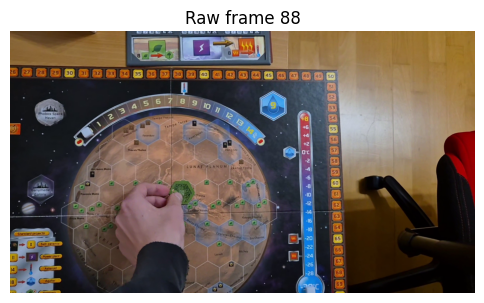

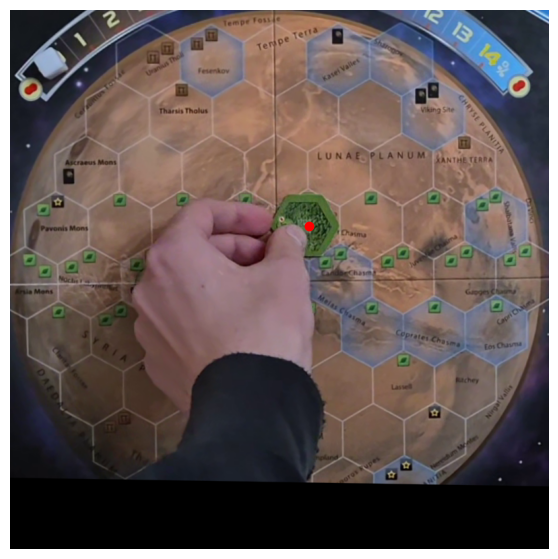

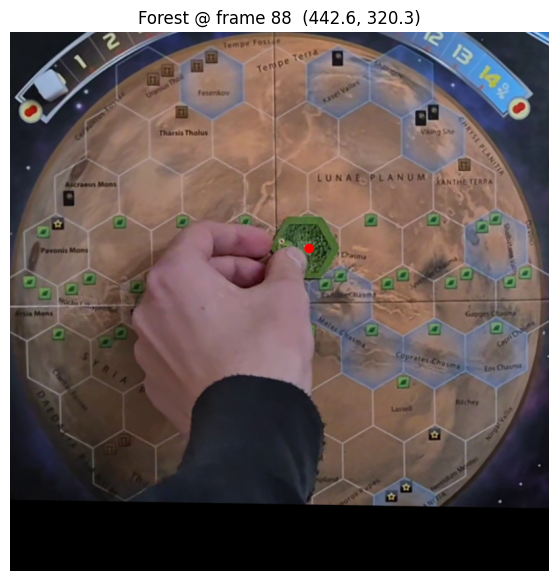

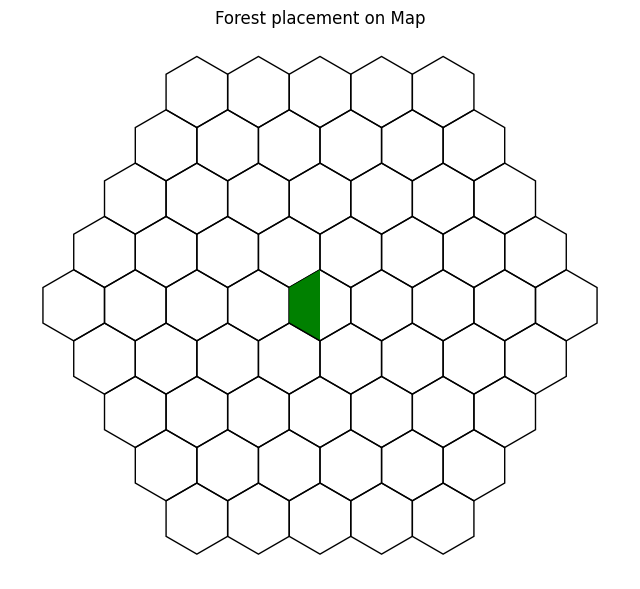

In [119]:
def read_frame_at(video_path, frame_idx_1based):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx_1based - 1)
    ok, frame = cap.read()
    cap.release()
    return frame if ok else None

def find_homography_board_to_map(board_topdown_bgr, map_template, orb, map_size,
                                 ratio=0.75, min_good=20, ransac_thresh=4.0,
                                 min_inliers=25):
    """
    Returns H_board_to_map that warps BOARD_TOPDOWN -> MAP (map_size).
    Uses ORB against `map_template` (Template instance of the map region).
    """
    gray = cv2.cvtColor(board_topdown_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(map_template.des, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good.append(m)

    if len(good) < min_good:
        return None

    src_pts = np.float32([map_template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # H maps TEMPLATE(map_template.img coords) -> BOARD coords
    H_tmpl_to_board, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    if H_tmpl_to_board is None:
        return None

    inlier_count = int(inliers.sum()) if inliers is not None else 0
    if inlier_count < min_inliers:
        return None

    # We want BOARD -> TEMPLATE, then scale TEMPLATE -> MAP_SIZE
    H_board_to_tmpl = np.linalg.inv(H_tmpl_to_board)

    tw = map_template.img.shape[1]
    th = map_template.img.shape[0]
    MW, MH = map_size

    S = np.array([[MW / tw, 0, 0],
                  [0, MH / th, 0],
                  [0, 0, 1]], dtype=np.float64)

    return S @ H_board_to_tmpl

def draw_forest_from_event_frame(
    video_path,
    event,
    orb,
    board_template,
    map_template,
    board_size=(1200,1200),
    map_size=(800,800),
):
    # 1) Read final frame
    frame = read_frame_at(video_path, event["frame_idx"])
    if frame is None:
        raise RuntimeError("Could not read event frame")

    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Raw frame {event['frame_idx']}")
    plt.axis("off")
    plt.show()

    map_topdown = cv2.warpPerspective(frame, event["H_frame_to_map"], (800, 800))

    x_map, y_map = event["pos_map_xy"]

    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(map_topdown, cv2.COLOR_BGR2RGB))
    plt.plot([x_map], [y_map], "ro")
    plt.axis("off")
    plt.show()


    # 5) Forest position in map coords
    # If you trust the event's map coords already, you can keep them.
    # Here we recompute from the event's frame center (more “by-the-book”).
    x_map, y_map = event["pos_map_xy"]

    # 6) Draw map + point
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(map_topdown, cv2.COLOR_BGR2RGB))
    plt.plot([x_map], [y_map], "ro")
    plt.title(f"Forest @ frame {event['frame_idx']}  ({x_map:.1f}, {y_map:.1f})")
    plt.axis("off")
    plt.show()

    return (x_map, y_map), map_topdown

# run:
pos_map_xy, map_img = draw_forest_from_event_frame(
    VIDEO_PATH,
    event,
    orb=orb,
    board_template=dataset["board"]["board"],
    map_template=dataset["regions"]["map"],
    board_size=(1200,1200),
    map_size=(800,800),
)

x_map, y_map = pos_map_xy

MW = 800
hex_size_px = MW / (9 * 1.5)
map_model = Map(hex_size=hex_size_px)

r, c = map_model.nearest_hex(x_map, y_map)
map_model.place_forest(r, c)

map_model.draw(title="Forest placement on Map")


In [120]:
def roi_from_corners(corners_map, pad=20, map_size=(800, 800)):
    """
    Compute an axis-aligned ROI (x, y, w, h) from projected polygon corners.

    corners_map : np.ndarray shape (4,1,2) or (4,2)
                  Forest tile corners in MAP coordinates
    pad         : extra pixels added on all sides
    map_size    : (width, height) of map image

    Returns:
        (x, y, w, h) clipped to map bounds
    """
    pts = corners_map.reshape(-1, 2)

    minx = float(pts[:, 0].min()) - pad
    maxx = float(pts[:, 0].max()) + pad
    miny = float(pts[:, 1].min()) - pad
    maxy = float(pts[:, 1].max()) + pad

    MW, MH = map_size

    x0 = max(0, int(np.floor(minx)))
    y0 = max(0, int(np.floor(miny)))
    x1 = min(MW, int(np.ceil(maxx)))
    y1 = min(MH, int(np.ceil(maxy)))

    w = x1 - x0
    h = y1 - y0

    if w <= 0 or h <= 0:
        raise ValueError("Invalid ROI computed from corners")

    return (x0, y0, w, h)


def detect_cube_blob_bgdiff(bg_gray, curr_gray, roi_xywh,
                            diff_thresh=12, min_area=10, max_area=2500):
    x, y, w, h = roi_xywh
    x0 = max(0, int(x)); y0 = max(0, int(y))
    x1 = min(curr_gray.shape[1], int(x + w))
    y1 = min(curr_gray.shape[0], int(y + h))
    if x1 - x0 < 12 or y1 - y0 < 12:
        return None

    a = bg_gray[y0:y1, x0:x1]
    b = curr_gray[y0:y1, x0:x1]

    d = cv2.absdiff(b, a)
    d = cv2.GaussianBlur(d, (5, 5), 0)
    _, mask = cv2.threshold(d, diff_thresh, 255, cv2.THRESH_BINARY)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8), iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    # forest ROI center (prefer cube near center)
    fx = (x0 + x1) / 2.0
    fy = (y0 + y1) / 2.0

    best = None
    best_score = -1e9

    for c in contours:
        area = float(cv2.contourArea(c))
        if area < min_area or area > max_area:
            continue

        bx, by, bw, bh = cv2.boundingRect(c)

        # cube-ish geometry
        ar = bw / (bh + 1e-6)
        if ar < 0.45 or ar > 2.2:
            continue

        extent = area / (bw * bh + 1e-6)  # 1.0 = solid rectangle
        if extent < 0.30:
            continue

        cx = x0 + bx + bw / 2.0
        cy = y0 + by + bh / 2.0
        dist = ((cx - fx)**2 + (cy - fy)**2) ** 0.5

        # score: compact + near center + not huge
        score = (2.5 * extent) - (0.004 * dist) - (0.0006 * area)

        if score > best_score:
            best_score = score
            best = (area, (float(cx), float(cy)), (x0 + bx, y0 + by, bw, bh), mask)

    if best is None:
        return None

    area, center_xy, bbox_xywh, mask = best
    return {"area": area, "center_xy": center_xy, "bbox_xywh": bbox_xywh, "mask": mask}

def detect_cube_after_forest_placed(
    video_path,
    orb,
    board_template,
    map_template,
    forest_event,
    board_size=(1200,1200),
    map_size=(800,800),
    refresh_every=3,
    max_frames=None,

    roi_pad=35,

    # background build
    bg_collect_frames=12,      # how many stable frames to build background
    bg_motion_thresh=12.0,     # ROI must be calmer than this to count as background frame

    # blob detection
    diff_thresh=12,
    min_blob_area=10,
    max_blob_area=2500,

    # “placed” conditions
    stable_frames=2,           # center stays near same place
    center_tol_px=10,
    cube_still_thresh=10.0,    # cube ROI stillness must be below this
    placed_frames=4,           # must be still this many consecutive frames
    roi_still_thresh=14.0,     # whole ROI must be calm (hand gone)

    debug=True
):
    start_frame = forest_event["frame_idx"]
    roi_xywh = roi_from_corners(forest_event["corners_map"], pad=roi_pad, map_size=map_size)

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    def close(p1, p2, tol=center_tol_px):
        return abs(p1[0]-p2[0]) <= tol and abs(p1[1]-p2[1]) <= tol

    prev_map_gray = None
    bg_samples = []
    bg_gray = None
    bg_frozen = False

    best = None
    stable = 0
    still_count = 0

    if debug:
        print("🧊 ROI:", roi_xywh, "start_frame:", start_frame)

    for frame_idx, frame, map_topdown, H_frame_to_map in iter_video_mapspace(
        video_path,
        orb,
        board_template,
        map_template,
        board_size=board_size,
        map_size=map_size,
        refresh_every=refresh_every,
        max_frames=max_frames
    ):
        if frame_idx < start_frame:
            continue

        map_gray = cv2.cvtColor(map_topdown, cv2.COLOR_BGR2GRAY)

        if prev_map_gray is None:
            prev_map_gray = map_gray
            continue

        # ROI motion (hand/shadow indicator)
        roi_center = (roi_xywh[0] + roi_xywh[2]/2.0, roi_xywh[1] + roi_xywh[3]/2.0)
        roi_motion = roi_stillness(prev_map_gray, map_gray, roi_center, roi_size=min(roi_xywh[2], roi_xywh[3]))

        # 1) Build background from calm frames
        if bg_gray is None:
            if roi_motion < bg_motion_thresh:
                # store ROI crop as background sample
                x,y,w,h = roi_xywh
                crop = map_gray[int(y):int(y+h), int(x):int(x+w)].copy()
                if crop.size > 0:
                    bg_samples.append(crop)
                    if debug and len(bg_samples) % 4 == 0:
                        print(f"  bg_samples={len(bg_samples)}/{bg_collect_frames}")

                if len(bg_samples) >= bg_collect_frames:
                    # median background in ROI
                    stack = np.stack(bg_samples, axis=0).astype(np.uint8)
                    bg_roi = np.median(stack, axis=0).astype(np.uint8)

                    # write bg back into full-size bg_gray
                    bg_gray = map_gray.copy()
                    bg_gray[int(y):int(y+h), int(x):int(x+w)] = bg_roi

                    if debug:
                        print("✅ background built")
            prev_map_gray = map_gray
            continue

        # 2) Detect blob vs background (cube candidate)
        blob = detect_cube_blob_bgdiff(
            bg_gray, map_gray, roi_xywh,
            diff_thresh=diff_thresh,
            min_area=min_blob_area,
            max_area=max_blob_area
        )

        if blob is None:
            best = None
            stable = 0
            still_count = 0
            prev_map_gray = map_gray
            continue

        # freeze bg once we see any candidate (prevents “learning away” the cube)
        if not bg_frozen:
            bg_frozen = True
            if debug:
                print("🧊 background frozen (candidate appeared)")

        # 3) “Placed” gates: cube still + ROI calm
        cube_still = roi_stillness(prev_map_gray, map_gray, blob["center_xy"], roi_size=140)

        if cube_still > cube_still_thresh or roi_motion > roi_still_thresh:
            best = None
            stable = 0
            still_count = 0
            prev_map_gray = map_gray
            continue

        cand = {
            "frame_idx": frame_idx,
            "time_sec": frame_idx / fps,
            "pos_map_xy": blob["center_xy"],
            "bbox_xywh": blob["bbox_xywh"],
            "area": blob["area"],
            "H_frame_to_map": H_frame_to_map,
            "roi_xywh": roi_xywh
        }

        if best is None:
            best = cand
            stable = 1
            still_count = 1
        else:
            if close(best["pos_map_xy"], cand["pos_map_xy"]):
                stable += 1
                still_count += 1
                # keep the tighter bbox if you want; for now keep latest
                best = cand
            else:
                best = cand
                stable = 1
                still_count = 1

        if debug and frame_idx % 20 == 0:
            print(f"f={frame_idx} stable={stable}/{stable_frames} still={still_count}/{placed_frames} "
                  f"cube_still={cube_still:.2f} roi_motion={roi_motion:.2f}")

        if stable >= stable_frames and still_count >= placed_frames:
            if debug:
                print(f"✅ cube PLACED @ frame {best['frame_idx']} pos={best['pos_map_xy']}")
            return best

        prev_map_gray = map_gray

    return None

def classify_cube_color(map_bgr, bbox_xywh):
    x, y, w, h = bbox_xywh
    x0 = max(0, int(x)); y0 = max(0, int(y))
    x1 = min(map_bgr.shape[1], int(x + w))
    y1 = min(map_bgr.shape[0], int(y + h))

    roi = map_bgr[y0:y1, x0:x1]
    if roi.size == 0:
        return "unknown"

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    H = hsv[...,0].astype(np.float32)
    S = hsv[...,1].astype(np.float32)
    V = hsv[...,2].astype(np.float32)

    # use only “real color” pixels (ignore shadow/specular)
    m = (S > 60) & (V > 60)

    Hh = H[m]
    Ss = S[m]
    Vs = V[m]

    if Hh.size < 10:
        return "unknown"

    # --- BLACK: very dark overall ---
    if np.mean(Vs) < 55:
        return "black"

    # Count hue votes
    red_votes   = np.sum((Hh < 10) | (Hh > 170))
    green_votes = np.sum((Hh >= 35) & (Hh <= 90) & (Ss > 60))
    blue_votes  = np.sum((Hh >= 95) & (Hh <= 135) & (Ss > 60))

    total = Hh.size

    # Require a *dominant* color (prevents noise)
    if green_votes / total > 0.45:
        return "green"
    if blue_votes / total > 0.45:
        return "blue"
    if red_votes / total > 0.35:
        return "red"

    return "orange"

def draw_cube_on_map(video_path, cube_event, map_size=(800,800), forest_event=None):
    frame = read_frame_at(video_path, cube_event["frame_idx"])
    map_topdown = cv2.warpPerspective(frame, cube_event["H_frame_to_map"], map_size)

    dbg = map_topdown.copy()

    if forest_event is not None and "corners_map" in forest_event:
        fpts = forest_event["corners_map"].reshape(-1,2).astype(int)
        cv2.polylines(dbg, [fpts], True, (0,255,0), 2)

    x,y,w,h = cube_event["bbox_xywh"]
    cv2.rectangle(dbg, (x,y), (x+w, y+h), (255,0,0), 2)

    cx = int(cube_event["pos_map_xy"][0])
    cy = int(cube_event["pos_map_xy"][1])
    cv2.circle(dbg, (cx,cy), 6, (0,0,255), -1)

    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(dbg, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return map_topdown

In [128]:
from collections import deque

def global_motion(prev_gray, curr_gray, step=32):
    a = cv2.GaussianBlur(prev_gray, (5, 5), 0)[::step, ::step]
    b = cv2.GaussianBlur(curr_gray, (5, 5), 0)[::step, ::step]
    return float(cv2.absdiff(a, b).mean())



def build_template_variants(base_template, orb,
                            scales=(0.20, 0.25, 0.33, 0.4, 0.5, 0.67, 0.8, 1.0)):
    variants = []
    base = base_template.img  # grayscale
    h0, w0 = base.shape[:2]

    for s in scales:
        w = max(32, int(w0 * s))
        h = max(32, int(h0 * s))

        img = cv2.resize(base, (w, h), interpolation=cv2.INTER_AREA)

        kp, des = orb.detectAndCompute(img, None)
        if des is None or len(kp) < 10:
            continue

        corners = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]]).reshape(-1, 1, 2)

        anchor = np.float32([[w * 0.50, h * 0.58]]).reshape(-1, 1, 2)  # tweak 0.58 -> 0.52, 0.60, etc.

        variants.append(type("Tmp", (), {
            "img": img,
            "kp": kp,
            "des": des,
            "corners": corners,
            "anchor": anchor,
        })())

    return variants


def match_template_orb_homography(img_bgr, template_or_list, orb,
                                 ratio=0.75, min_good=8,
                                 ransac_thresh=4.0,
                                 min_inliers=10,
                                 area_range=(2500, 120000),
                                 debug=False):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    templates = template_or_list if isinstance(template_or_list, (list, tuple)) else [template_or_list]

    best = None

    for ti, template in enumerate(templates):
        knn = bf.knnMatch(template.des, des2, k=2)

        good = []
        for pair in knn:
            if len(pair) == 2:
                m, n = pair
                if m.distance < ratio * n.distance:
                    good.append(m)

        if len(good) < min_good:
            continue

        src_pts = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        H, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
        if H is None:
            continue

        inlier_count = int(inliers.sum()) if inliers is not None else 0
        if inlier_count < min_inliers:
            continue

        corners = cv2.perspectiveTransform(template.corners, H)
        pts = corners.reshape(-1, 2)

        h, w = gray.shape[:2]
        margin = 10
        if (pts[:, 0].min() < -margin or pts[:, 0].max() > w + margin or
            pts[:, 1].min() < -margin or pts[:, 1].max() > h + margin):
            continue

        area = abs(cv2.contourArea(pts.astype(np.float32)))
        if area < area_range[0] or area > area_range[1]:
            continue

        a = cv2.perspectiveTransform(template.anchor, H).reshape(2,)
        cx, cy = float(a[0]), float(a[1])

        cand = {
            "good": len(good),
            "inliers": inlier_count,
            "corners": corners,
            "center": (cx, cy),
            "area": float(area),
            "variant_idx": ti,
        }

        if best is None or (cand["inliers"], cand["good"]) > (best["inliers"], best["good"]):
            best = cand

    return best


def roi_mean_absdiff(a_gray, b_gray, center_xy, roi_size=160):
    cx = int(round(center_xy[0]))
    cy = int(round(center_xy[1]))

    h, w = b_gray.shape[:2]
    r = roi_size // 2

    x0 = max(0, cx - r)
    x1 = min(w, cx + r)
    y0 = max(0, cy - r)
    y1 = min(h, cy + r)

    if (x1 - x0) < 10 or (y1 - y0) < 10:
        return 1e9

    diff = cv2.absdiff(a_gray[y0:y1, x0:x1], b_gray[y0:y1, x0:x1])
    return float(diff.mean())


def merge_nearby_events(events, dist_px=90, time_s=2.5):
    merged = []
    for e in events:
        if not merged:
            merged.append(e)
            continue

        last = merged[-1]
        dx = e["pos_map_xy"][0] - last["pos_map_xy"][0]
        dy = e["pos_map_xy"][1] - last["pos_map_xy"][1]
        dt = e["time_sec"] - last["time_sec"]
        d = (dx * dx + dy * dy) ** 0.5

        if dt <= time_s and d <= dist_px and e["tile"] == last["tile"]:
            if (e["inliers"], e["good_matches"]) > (last["inliers"], last["good_matches"]):
                merged[-1] = e
        else:
            merged.append(e)

    return merged

def snap_to_hex(p, centers):
    px, py = p
    best = None
    best_d2 = 1e18
    for cx, cy in centers:
        dx = px - cx; dy = py - cy
        d2 = dx*dx + dy*dy
        if d2 < best_d2:
            best_d2 = d2
            best = (cx, cy)
    return best, best_d2


def detect_all_tile_placements(
    video_path,
    orb,
    board_template,
    map_template,
    tile_templates,               # dict: {"forest": tmpl, "city": tmpl, "ocean": tmpl}
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=3,
    max_frames=None,
    ratio=0.75,
    min_good=6,
    min_inliers=6,
    ransac_thresh=5.0,
    area_range=(800, 200000),
    stable_frames=2,
    center_tol_px=40,
    roi_size=200,
    still_thresh=12.0,

    # NEW: ambiguity rejection (winner must beat runner-up)
    min_inlier_margin=4,
    min_good_margin=4,

    # NEW: "tile appears" check (must differ from earlier baseline)
    appear_lookback_sec=0.8,
    appear_thresh=10.0,

    # NEW: duplicate prevention
    occupied_tol_px=90,
    cooldown_sec=1.2,

    debug=False,
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    cooldown_frames = int(cooldown_sec * fps)
    lookback_frames = max(1, int(appear_lookback_sec * fps))

    # Build scale pyramids once
    tile_variants = {
        name: build_template_variants(tmpl, orb)
        for name, tmpl in tile_templates.items()
    }

    def close(p1, p2):
        return abs(p1[0] - p2[0]) <= center_tol_px and abs(p1[1] - p2[1]) <= center_tol_px

    # occupied per tile-type (prevents double-fire same tile near same spot)
    occupied = {name: [] for name in tile_templates.keys()}

    def already_logged(tile, pos):
        for ox, oy in occupied[tile]:
            dx = pos[0] - ox
            dy = pos[1] - oy
            if dx * dx + dy * dy <= occupied_tol_px * occupied_tol_px:
                return True
        return False

    def best_tile_match_with_margin(map_img):
        scored = []
        for name, variants in tile_variants.items():
            m = match_template_orb_homography(
                map_img, variants, orb,
                ratio=ratio,
                min_good=min_good,
                ransac_thresh=ransac_thresh,
                min_inliers=min_inliers,
                area_range=area_range,
                debug=False
            )
            if m is not None:
                scored.append((name, m))

        if not scored:
            return None, None

        scored.sort(key=lambda x: (x[1]["inliers"], x[1]["good"]), reverse=True)
        best_name, best_m = scored[0]
        second_m = scored[1][1] if len(scored) > 1 else None

        if best_name == "ocean":
            return best_name, best_m

        # Ambiguity rejection: if winner is not clearly better, skip this frame
        if second_m is not None:
            if (best_m["inliers"] < second_m["inliers"] + min_inlier_margin and
                best_m["good"]   < second_m["good"]   + min_good_margin):
                return None, None

        return best_name, best_m

    # store recent map grays for appearance check
    prev_map_gray = None
    gray_history = deque(maxlen=lookback_frames + 1)

    events = []
    candidate = None
    stable_count = 0
    lost_count = 0
    cooldown = 0
    lost_frames_needed = 2

    for frame_idx, frame, map_topdown, H_frame_to_map in iter_video_mapspace(
        video_path,
        orb,
        board_template,
        map_template,
        board_size=board_size,
        map_size=map_size,
        refresh_every=refresh_every,
        max_frames=max_frames
    ):
        map_gray = cv2.cvtColor(map_topdown, cv2.COLOR_BGR2GRAY)
        gray_history.append(map_gray)

        if prev_map_gray is None:
            prev_map_gray = map_gray
            continue

        shake = global_motion(prev_map_gray, map_gray, step=32)

        if cooldown > 0:
            cooldown -= 1
            prev_map_gray = map_gray
            continue

        tile, m = best_tile_match_with_margin(map_topdown)

        if m is None:
            lost_count += 1
            if lost_count >= lost_frames_needed:
                candidate = None
                stable_count = 0
            prev_map_gray = map_gray
            continue

        lost_count = 0

        # stillness: reject hand motion / big shadow movement
        still = roi_mean_absdiff(prev_map_gray, map_gray, m["center"], roi_size=roi_size)
        if still > still_thresh:
            candidate = None
            stable_count = 0
            prev_map_gray = map_gray
            continue

        # appearance: tile must have "appeared" compared to older frame
        if len(gray_history) >= lookback_frames + 1:
            old_gray = gray_history[0]
            appear = roi_mean_absdiff(old_gray, map_gray, m["center"], roi_size=roi_size)
            if appear < max(appear_thresh, shake * 1.8):
                candidate = None
                stable_count = 0
                prev_map_gray = map_gray
                continue

        else:
            appear = None

        cand = {
            "tile": tile,
            "frame_idx": frame_idx,
            "time_sec": frame_idx / fps,
            "pos_map_xy": m["center"],
            "corners_map": m["corners"],
            "inliers": m["inliers"],
            "good_matches": m["good"],
            "area": m["area"],
            "stillness": still,
            "appear": appear,
            "H_frame_to_map": H_frame_to_map
        }

        # build stability over consecutive frames
        if candidate is None or candidate["tile"] != tile or not close(candidate["pos_map_xy"], cand["pos_map_xy"]):
            candidate = cand
            stable_count = 1
        else:
            # same hypothesis: keep stronger
            if (cand["inliers"], cand["good_matches"]) > (candidate["inliers"], candidate["good_matches"]):
                candidate = cand
            stable_count += 1

        if stable_count >= stable_frames:
            # prevent duplicates: same tile near same spot -> ignore
            if already_logged(candidate["tile"], candidate["pos_map_xy"]):
                if debug:
                    print(f"↩️ duplicate ignored: {candidate['tile']} @ {candidate['time_sec']:.2f}s")
                candidate = None
                stable_count = 0
                cooldown = int(0.5 * fps)
                prev_map_gray = map_gray
                continue

            events.append(candidate)
            occupied[candidate["tile"]].append(candidate["pos_map_xy"])

            if debug:
                print(f"✅ {candidate['tile']} placed @ {candidate['time_sec']:.2f}s pos={candidate['pos_map_xy']}")

            candidate = None
            stable_count = 0
            cooldown = cooldown_frames

        prev_map_gray = map_gray

    # extra safety: merge any remaining near-duplicates
    events = merge_nearby_events(events, dist_px=occupied_tol_px, time_s=max(2.0, cooldown_sec * 2.0))
    return events


In [122]:
events = detect_all_tile_placements(
    VIDEO_PATH,
    orb=orb,
    board_template=dataset["board"]["board"],
    map_template=dataset["regions"]["map"],
    tile_templates={
        "forest": dataset["pieces"]["forest"],
        "city":  dataset["pieces"]["city"],
        "ocean": dataset["pieces"]["ocean"],
    },
    refresh_every=3,
    stable_frames=2,
    roi_size=200,
    still_thresh=12.0,
    appear_lookback_sec=0.8,
    appear_thresh=10.0,
    min_inlier_margin=4,
    min_good_margin=4,
    occupied_tol_px=90,
    cooldown_sec=1.2,
    debug=True,
)


✅ forest placed @ 2.93s pos=(442.5663757324219, 320.3035888671875)
↩️ duplicate ignored: forest @ 4.17s
↩️ duplicate ignored: forest @ 4.97s
↩️ duplicate ignored: forest @ 6.63s
↩️ duplicate ignored: forest @ 7.63s
✅ city placed @ 13.97s pos=(354.7073974609375, 330.6246643066406)
↩️ duplicate ignored: city @ 15.24s
↩️ duplicate ignored: city @ 15.84s
↩️ duplicate ignored: city @ 16.44s
✅ ocean placed @ 28.84s pos=(380.5758972167969, 397.6717529296875)
↩️ duplicate ignored: ocean @ 33.27s
↩️ duplicate ignored: ocean @ 34.17s
↩️ duplicate ignored: ocean @ 34.84s
✅ forest placed @ 35.84s pos=(404.90777587890625, 229.8188018798828)
↩️ duplicate ignored: ocean @ 42.14s


In [123]:
def roi_from_corners(corners_map, pad=20, map_size=(800, 800)):
    pts = corners_map.reshape(-1, 2)

    minx = float(pts[:, 0].min()) - pad
    maxx = float(pts[:, 0].max()) + pad
    miny = float(pts[:, 1].min()) - pad
    maxy = float(pts[:, 1].max()) + pad

    MW, MH = map_size
    x0 = max(0, int(np.floor(minx)))
    y0 = max(0, int(np.floor(miny)))
    x1 = min(MW, int(np.ceil(maxx)))
    y1 = min(MH, int(np.ceil(maxy)))

    w = x1 - x0
    h = y1 - y0
    if w <= 0 or h <= 0:
        raise ValueError("Invalid ROI computed from corners")

    return (x0, y0, w, h)


def detect_cube_blob_bgdiff(bg_gray, curr_gray, roi_xywh,
                            diff_thresh=12, min_area=10, max_area=2500):
    x, y, w, h = roi_xywh
    x0 = max(0, int(x)); y0 = max(0, int(y))
    x1 = min(curr_gray.shape[1], int(x + w))
    y1 = min(curr_gray.shape[0], int(y + h))
    if x1 - x0 < 12 or y1 - y0 < 12:
        return None

    a = bg_gray[y0:y1, x0:x1]
    b = curr_gray[y0:y1, x0:x1]

    d = cv2.absdiff(b, a)
    d = cv2.GaussianBlur(d, (5, 5), 0)
    _, mask = cv2.threshold(d, diff_thresh, 255, cv2.THRESH_BINARY)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8), iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    # ROI center (prefer cube near center)
    fx = (x0 + x1) / 2.0
    fy = (y0 + y1) / 2.0

    best = None
    best_score = -1e9

    for c in contours:
        area = float(cv2.contourArea(c))
        if area < min_area or area > max_area:
            continue

        bx, by, bw, bh = cv2.boundingRect(c)

        ar = bw / (bh + 1e-6)
        if ar < 0.45 or ar > 2.2:
            continue

        extent = area / (bw * bh + 1e-6)
        if extent < 0.30:
            continue

        cx = x0 + bx + bw / 2.0
        cy = y0 + by + bh / 2.0
        dist = ((cx - fx)**2 + (cy - fy)**2) ** 0.5

        score = (2.5 * extent) - (0.004 * dist) - (0.0006 * area)

        if score > best_score:
            best_score = score
            best = (area, (float(cx), float(cy)), (x0 + bx, y0 + by, bw, bh), mask)

    if best is None:
        return None

    area, center_xy, bbox_xywh, mask = best
    return {"area": area, "center_xy": center_xy, "bbox_xywh": bbox_xywh, "mask": mask}


def detect_cube_after_tile_placed(
    video_path,
    orb,
    board_template,
    map_template,
    tile_event,                      # event for forest OR city (must have frame_idx + corners_map)
    board_size=(1200,1200),
    map_size=(800,800),
    refresh_every=3,
    max_frames=None,

    roi_pad=35,

    # search window
    start_delay_sec=0.2,              # wait a bit after tile placement
    max_after_sec=4.0,                # stop searching after this many seconds

    # background build
    bg_collect_frames=12,
    bg_motion_thresh=12.0,

    # blob detection
    diff_thresh=12,
    min_blob_area=10,
    max_blob_area=2500,

    # “placed” conditions
    stable_frames=2,
    center_tol_px=10,
    cube_still_thresh=10.0,
    placed_frames=4,
    roi_still_thresh=14.0,

    debug=False
):
    if "corners_map" not in tile_event:
        raise ValueError("tile_event must contain corners_map")

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    start_frame = tile_event["frame_idx"] + int(start_delay_sec * fps)
    end_frame = start_frame + int(max_after_sec * fps)

    roi_xywh = roi_from_corners(tile_event["corners_map"], pad=roi_pad, map_size=map_size)

    def close(p1, p2, tol=center_tol_px):
        return abs(p1[0]-p2[0]) <= tol and abs(p1[1]-p2[1]) <= tol

    prev_map_gray = None
    bg_samples = []
    bg_gray = None
    bg_frozen = False

    best = None
    stable = 0
    still_count = 0

    if debug:
        print("🧊 ROI:", roi_xywh, "start_frame:", start_frame, "end_frame:", end_frame)

    for frame_idx, frame, map_topdown, H_frame_to_map in iter_video_mapspace(
        video_path,
        orb,
        board_template,
        map_template,
        board_size=board_size,
        map_size=map_size,
        refresh_every=refresh_every,
        max_frames=max_frames
    ):
        if frame_idx < start_frame:
            continue
        if frame_idx > end_frame:
            return None

        map_gray = cv2.cvtColor(map_topdown, cv2.COLOR_BGR2GRAY)

        if prev_map_gray is None:
            prev_map_gray = map_gray
            continue

        # ROI motion (hand/shadow indicator)
        roi_center = (roi_xywh[0] + roi_xywh[2]/2.0, roi_xywh[1] + roi_xywh[3]/2.0)
        roi_motion = roi_stillness(prev_map_gray, map_gray, roi_center, roi_size=min(roi_xywh[2], roi_xywh[3]))

        # 1) Build background from calm frames (pre-cube or calm post-cube)
        if bg_gray is None:
            if roi_motion < bg_motion_thresh:
                x, y, w, h = roi_xywh
                crop = map_gray[int(y):int(y+h), int(x):int(x+w)].copy()
                if crop.size > 0:
                    bg_samples.append(crop)
                    if debug and len(bg_samples) % 4 == 0:
                        print(f"  bg_samples={len(bg_samples)}/{bg_collect_frames}")

                if len(bg_samples) >= bg_collect_frames:
                    stack = np.stack(bg_samples, axis=0).astype(np.uint8)
                    bg_roi = np.median(stack, axis=0).astype(np.uint8)

                    bg_gray = map_gray.copy()
                    bg_gray[int(y):int(y+h), int(x):int(x+w)] = bg_roi

                    if debug:
                        print("✅ background built")

            prev_map_gray = map_gray
            continue

        # 2) Detect blob vs background (cube candidate)
        blob = detect_cube_blob_bgdiff(
            bg_gray, map_gray, roi_xywh,
            diff_thresh=diff_thresh,
            min_area=min_blob_area,
            max_area=max_blob_area
        )

        if blob is None:
            best = None
            stable = 0
            still_count = 0
            prev_map_gray = map_gray
            continue

        # freeze bg once we see any candidate (prevents “learning away” the cube)
        if not bg_frozen:
            bg_frozen = True
            if debug:
                print("🧊 background frozen (candidate appeared)")

        # 3) “Placed” gates: cube still + ROI calm
        cube_still = roi_stillness(prev_map_gray, map_gray, blob["center_xy"], roi_size=140)

        if cube_still > cube_still_thresh or roi_motion > roi_still_thresh:
            best = None
            stable = 0
            still_count = 0
            prev_map_gray = map_gray
            continue

        cand = {
            "frame_idx": frame_idx,
            "time_sec": frame_idx / fps,
            "pos_map_xy": blob["center_xy"],
            "bbox_xywh": blob["bbox_xywh"],
            "area": blob["area"],
            "H_frame_to_map": H_frame_to_map,
            "roi_xywh": roi_xywh
        }

        if best is None:
            best = cand
            stable = 1
            still_count = 1
        else:
            if close(best["pos_map_xy"], cand["pos_map_xy"]):
                stable += 1
                still_count += 1
                best = cand
            else:
                best = cand
                stable = 1
                still_count = 1

        if debug and frame_idx % 20 == 0:
            print(f"f={frame_idx} stable={stable}/{stable_frames} still={still_count}/{placed_frames} "
                  f"cube_still={cube_still:.2f} roi_motion={roi_motion:.2f}")

        if stable >= stable_frames and still_count >= placed_frames:
            if debug:
                print(f"✅ cube PLACED @ frame {best['frame_idx']} pos={best['pos_map_xy']}")
            return best

        prev_map_gray = map_gray

    return None


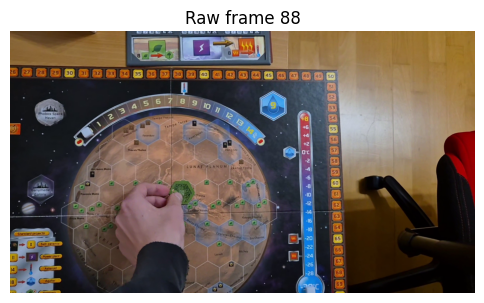

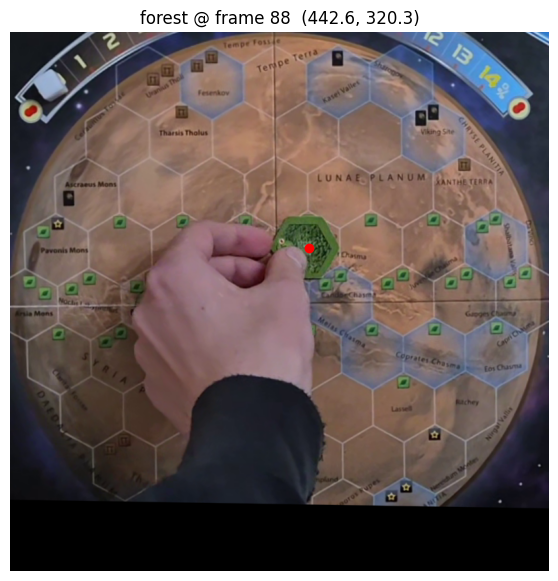

🧊 ROI: (355, 233, 179, 171) start_frame: 88
  bg_samples=4/12
  bg_samples=8/12
  bg_samples=12/12
✅ background built
🧊 background frozen (candidate appeared)
f=120 stable=1/2 still=1/4 cube_still=5.74 roi_motion=5.25
f=140 stable=1/2 still=1/4 cube_still=6.08 roi_motion=10.05
f=160 stable=2/2 still=2/4 cube_still=2.69 roi_motion=3.37
f=200 stable=1/2 still=1/4 cube_still=4.56 roi_motion=5.51
f=260 stable=1/2 still=1/4 cube_still=6.34 roi_motion=9.81
f=280 stable=1/2 still=1/4 cube_still=6.07 roi_motion=9.57
f=320 stable=1/2 still=1/4 cube_still=8.60 roi_motion=10.88
f=340 stable=1/2 still=1/4 cube_still=4.99 roi_motion=6.31
f=380 stable=1/2 still=1/4 cube_still=9.26 roi_motion=9.49
f=400 stable=1/2 still=1/4 cube_still=6.95 roi_motion=10.01
f=420 stable=1/2 still=1/4 cube_still=7.90 roi_motion=8.37
f=460 stable=1/2 still=1/4 cube_still=4.34 roi_motion=6.81
f=480 stable=1/2 still=1/4 cube_still=8.30 roi_motion=13.39
f=500 stable=1/2 still=1/4 cube_still=4.21 roi_motion=7.43
f=520 stabl

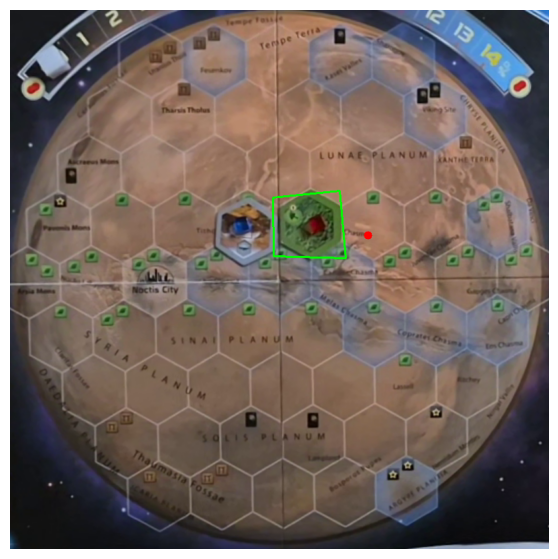

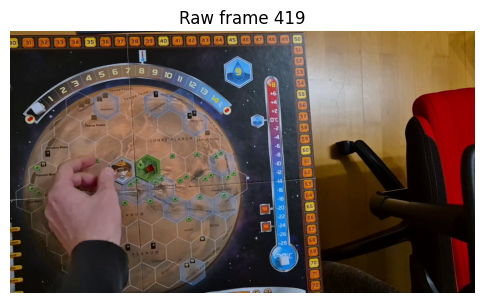

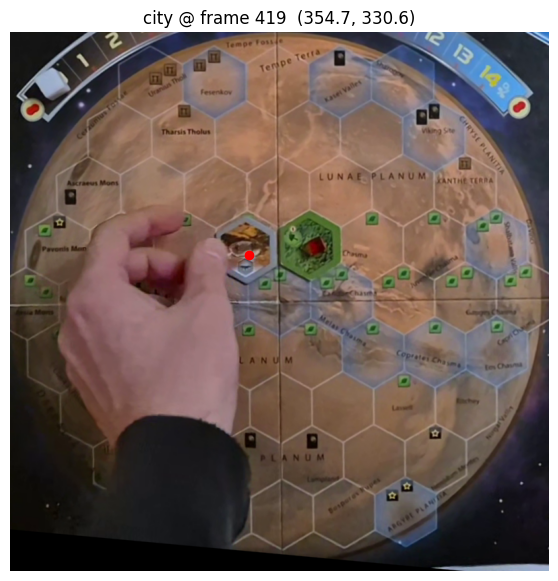

🧊 ROI: (256, 239, 193, 191) start_frame: 419
  bg_samples=4/12
  bg_samples=8/12
  bg_samples=12/12
✅ background built
🧊 background frozen (candidate appeared)
f=460 stable=1/2 still=1/4 cube_still=7.49 roi_motion=6.86
f=500 stable=1/2 still=1/4 cube_still=7.95 roi_motion=7.97
f=520 stable=1/2 still=1/4 cube_still=7.06 roi_motion=8.74
f=540 stable=1/2 still=1/4 cube_still=6.54 roi_motion=12.98
f=560 stable=1/2 still=1/4 cube_still=5.49 roi_motion=4.76
f=620 stable=1/2 still=1/4 cube_still=9.42 roi_motion=11.48
f=640 stable=1/2 still=1/4 cube_still=5.93 roi_motion=5.66
f=660 stable=1/2 still=1/4 cube_still=8.13 roi_motion=7.78
f=680 stable=1/2 still=1/4 cube_still=3.94 roi_motion=4.27
f=700 stable=1/2 still=1/4 cube_still=9.99 roi_motion=9.23
f=740 stable=1/2 still=1/4 cube_still=3.67 roi_motion=8.97
f=760 stable=1/2 still=1/4 cube_still=6.92 roi_motion=8.57
f=780 stable=1/2 still=1/4 cube_still=7.72 roi_motion=9.58
f=800 stable=1/2 still=1/4 cube_still=3.46 roi_motion=5.71
f=820 stable

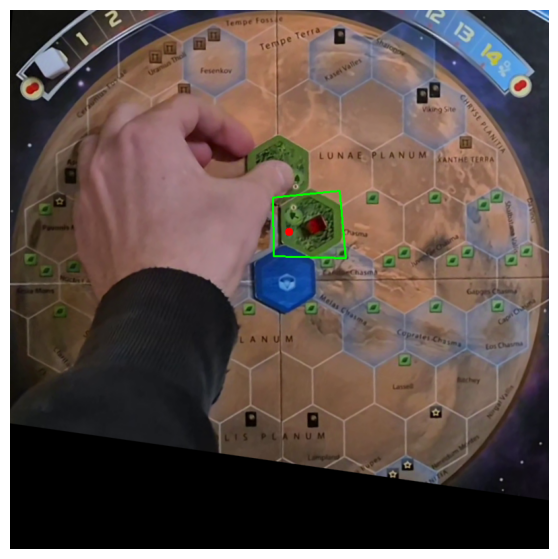

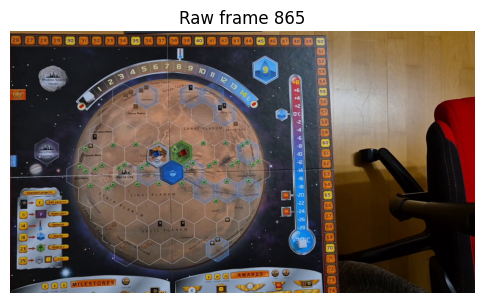

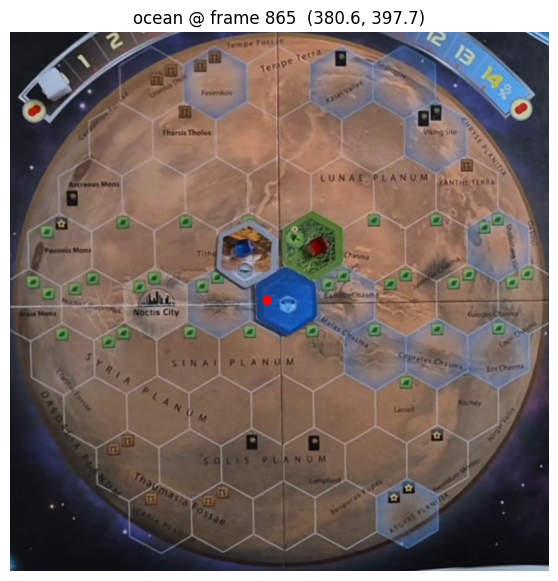

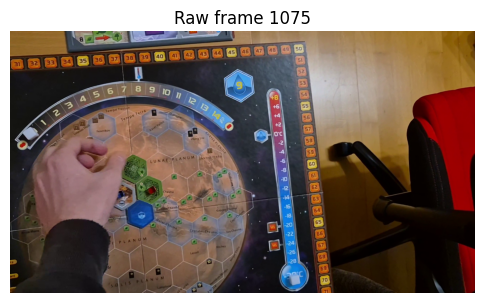

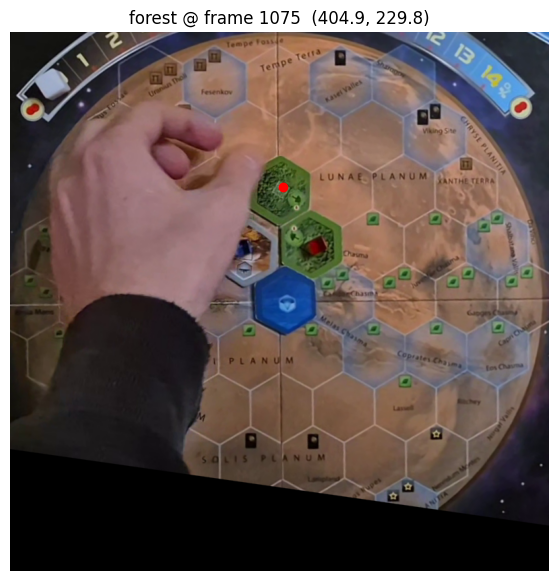

🧊 ROI: (307, 125, 212, 208) start_frame: 1075
  bg_samples=4/12
  bg_samples=8/12
  bg_samples=12/12
✅ background built
🧊 background frozen (candidate appeared)
f=1100 stable=1/2 still=1/4 cube_still=9.23 roi_motion=13.65
f=1120 stable=1/2 still=1/4 cube_still=1.29 roi_motion=1.84
f=1160 stable=2/2 still=2/4 cube_still=4.58 roi_motion=8.70
f=1180 stable=1/2 still=1/4 cube_still=3.76 roi_motion=4.76
f=1220 stable=1/2 still=1/4 cube_still=4.55 roi_motion=6.01
f=1240 stable=1/2 still=1/4 cube_still=6.68 roi_motion=8.69
f=1260 stable=1/2 still=1/4 cube_still=5.03 roi_motion=4.07
f=1280 stable=1/2 still=1/4 cube_still=3.88 roi_motion=5.96
f=1300 stable=1/2 still=1/4 cube_still=6.48 roi_motion=9.20
f=1340 stable=1/2 still=1/4 cube_still=2.15 roi_motion=3.52
f=1360 stable=1/2 still=1/4 cube_still=1.75 roi_motion=2.18
f=1380 stable=1/2 still=1/4 cube_still=5.77 roi_motion=5.75
f=1400 stable=1/2 still=1/4 cube_still=2.12 roi_motion=1.45
f=1420 stable=1/2 still=1/4 cube_still=3.75 roi_motion=4.3

In [126]:
def read_frame_at(video_path, frame_idx_1based):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx_1based - 1)
    ok, frame = cap.read()
    cap.release()
    return frame if ok else None

def find_homography_board_to_map(board_topdown_bgr, map_template, orb, map_size,
                                 ratio=0.75, min_good=20, ransac_thresh=4.0,
                                 min_inliers=25):
    """
    Returns H_board_to_map that warps BOARD_TOPDOWN -> MAP (map_size).
    Uses ORB against `map_template` (Template instance of the map region).
    """
    gray = cv2.cvtColor(board_topdown_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(map_template.des, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good.append(m)

    if len(good) < min_good:
        return None

    src_pts = np.float32([map_template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # H maps TEMPLATE(map_template.img coords) -> BOARD coords
    H_tmpl_to_board, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    if H_tmpl_to_board is None:
        return None

    inlier_count = int(inliers.sum()) if inliers is not None else 0
    if inlier_count < min_inliers:
        return None

    # We want BOARD -> TEMPLATE, then scale TEMPLATE -> MAP_SIZE
    H_board_to_tmpl = np.linalg.inv(H_tmpl_to_board)

    tw = map_template.img.shape[1]
    th = map_template.img.shape[0]
    MW, MH = map_size

    S = np.array([[MW / tw, 0, 0],
                  [0, MH / th, 0],
                  [0, 0, 1]], dtype=np.float64)

    return S @ H_board_to_tmpl

def draw_tile_from_event_frame(
    video_path,
    event,
    orb,
    board_template,
    map_template,
    board_size=(1200,1200),
    map_size=(800,800),
):
    # 1) Read final frame
    tile_type = event["tile"]
    frame = read_frame_at(video_path, event["frame_idx"])
    if frame is None:
        raise RuntimeError("Could not read event frame")

    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Raw frame {event['frame_idx']}")
    plt.axis("off")
    plt.show()

    map_topdown = cv2.warpPerspective(frame, event["H_frame_to_map"], (800, 800))

    x_map, y_map = event["pos_map_xy"]

    # 5) Forest position in map coords
    # If you trust the event's map coords already, you can keep them.
    # Here we recompute from the event's frame center (more “by-the-book”).
    x_map, y_map = event["pos_map_xy"]

    # 6) Draw map + point
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(map_topdown, cv2.COLOR_BGR2RGB))
    plt.plot([x_map], [y_map], "ro")
    plt.title(f"{tile_type} @ frame {event['frame_idx']}  ({x_map:.1f}, {y_map:.1f})")
    plt.axis("off")
    plt.show()

    return (x_map, y_map), map_topdown



MW = 800
hex_size_px = MW / (9 * 1.5)
map_model = Map(hex_size=hex_size_px)

for e in events:
    pos_map_xy, map_img = draw_tile_from_event_frame(
        VIDEO_PATH,
        e,
        orb=orb,
        board_template=dataset["board"]["board"],
        map_template=dataset["regions"]["map"],
        board_size=(1200,1200),
        map_size=(800,800),
    )
    tile_type = e["tile"]
    x_map, y_map = pos_map_xy
    r, c = map_model.nearest_hex(x_map, y_map)
    map_model.place_tile(r, c, tile_type=tile_type)

    if tile_type == "ocean":
        continue

    cube_event = detect_cube_after_forest_placed(
        VIDEO_PATH,
        orb=orb,
        board_template=dataset["board"]["board"],
        map_template=dataset["regions"]["map"],
        forest_event=e,
        refresh_every=3,
        diff_thresh=12,
        min_blob_area=10,
        max_blob_area=2500,
        stable_frames=2,
        placed_frames=4,
        cube_still_thresh=10.0,
        roi_still_thresh=14.0,
        debug=True
    )
    if cube_event is None:
        color = "purple"
    else:
        frame = read_frame_at(VIDEO_PATH, cube_event["frame_idx"])
        map_img = cv2.warpPerspective(frame, cube_event["H_frame_to_map"], (800,800))
        color = classify_cube_color(map_img, cube_event["bbox_xywh"])
        print("Cube color:", color)

        draw_cube_on_map(VIDEO_PATH, cube_event, forest_event=event)
    map_model.set_owner(r, c, color)


#r, c = map_model.nearest_hex(x_map, y_map)
#map_model.place_forest(r, c)

plt.show()


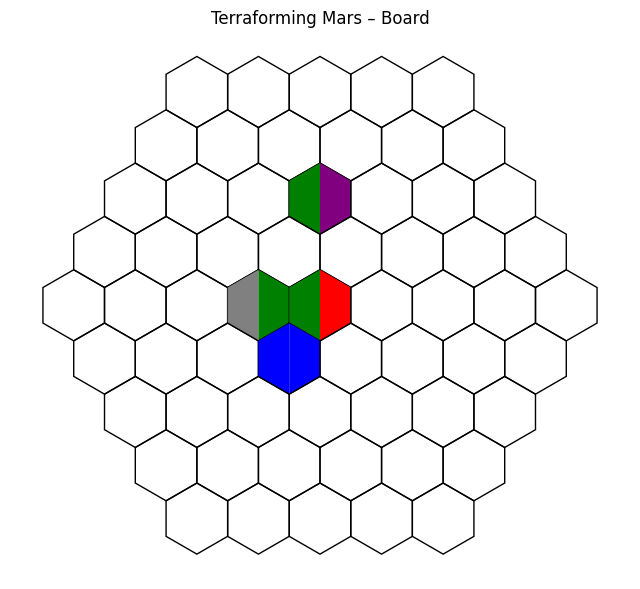

In [127]:
map_model.draw()